俩个数据集：mnist(手写数字识别),imagenet（自然物体识别）

分类问题（面向分n类）:输出o1,o2,o3---oN,分别作为n类的置信度水平
分类输出的常见表示：长度为n的向量，向量中每个值非负（代表每一种类对应出现概率），相加之和为1.

对应的元素位置为1，其余位为0
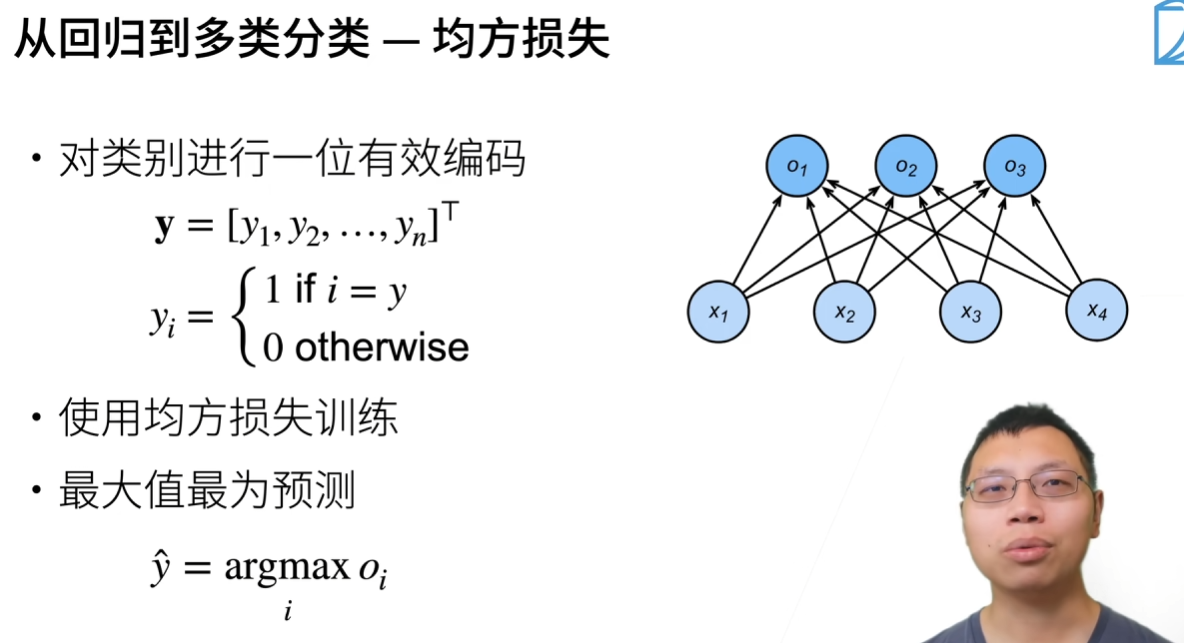

判断这个类的标准，就是这个类的置信度-其他类的置信度大于某一特定阈值
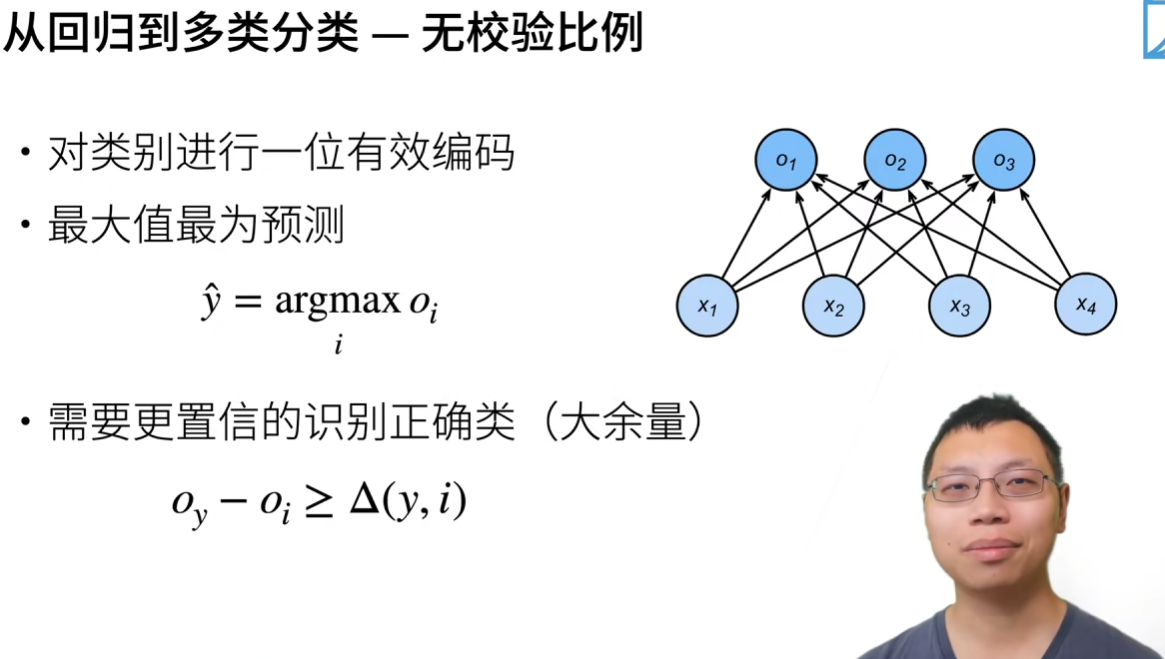

In [6]:
#softmax操作子：三步实现
"""
1.对原来的预测分数向量值取指数，例 y=[2.0,1.0,0.1]  exp_y=[7.39,2.72,1.11]
2.求和作为分母 sum_exp_y=7.39+2.72+1.11=11.22
3.将原来概率向量除以分母得到 y_hat=[7.39/11.22,2.72/11.22,1.11/11.22]=[0.66,0.24,0.10](和为1)

损失函数：交叉熵函数

交叉熵计算：看正确类别的概率，对它取负对数
loss = -log(0.66) = 0.415   ← 猫的概率 0.66，loss 是 0.415
loss = -log(0.99) = 0.010   ← 猫的概率 0.99，loss 很小
loss = -log(0.01) = 4.605   ← 猫的概率 0.01，loss 爆炸
"""

'\n1.对原来的预测分数向量值取指数，例 y=[2.0,1.0,0.1]  exp_y=[7.39,2.72,1.11]\n2.求和作为分母 sum_exp_y=7.39+2.72+1.11=11.22\n3.将原来概率向量除以分母得到 y_hat=[7.39/11.22,2.72/11.22,1.11/11.22]=[0.66,0.24,0.10](和为1)\n\n损失函数：交叉熵函数\n\n交叉熵计算：看正确类别的概率，对它取负对数\nloss = -log(0.66) = 0.415   ← 猫的概率 0.66，loss 是 0.415\nloss = -log(0.99) = 0.010   ← 猫的概率 0.99，loss 很小\nloss = -log(0.01) = 4.605   ← 猫的概率 0.01，loss 爆炸\n'

In [7]:
#常见三种损失函数
"""
1.均方误差：loss(y,y_hat)=1/2*(y-y_hat)**2
2.绝对值： loss(y,y_hat)=|y-y_hat|
3.鲁棒损失： 当预测值与真实值差距较大时（|y-y_hat|>1）: loss(y,y_hat)=|y-y_hat|-1/2
            当预测值与真实值差距较小时 loss(y,y_hat):[(y-y_hat)**2]/2
"""

'\n1.均方误差：loss(y,y_hat)=1/2*(y-y_hat)**2\n2.绝对值： loss(y,y_hat)=|y-y_hat|\n3.鲁棒损失： 当预测值与真实值差距较大时（|y-y_hat|>1）: loss(y,y_hat)=|y-y_hat|-1/2\n            当预测值与真实值差距较小时 loss(y,y_hat):[(y-y_hat)**2]/2\n'

蓝：损失函数

橙：损失函数梯度

绿：似然函数
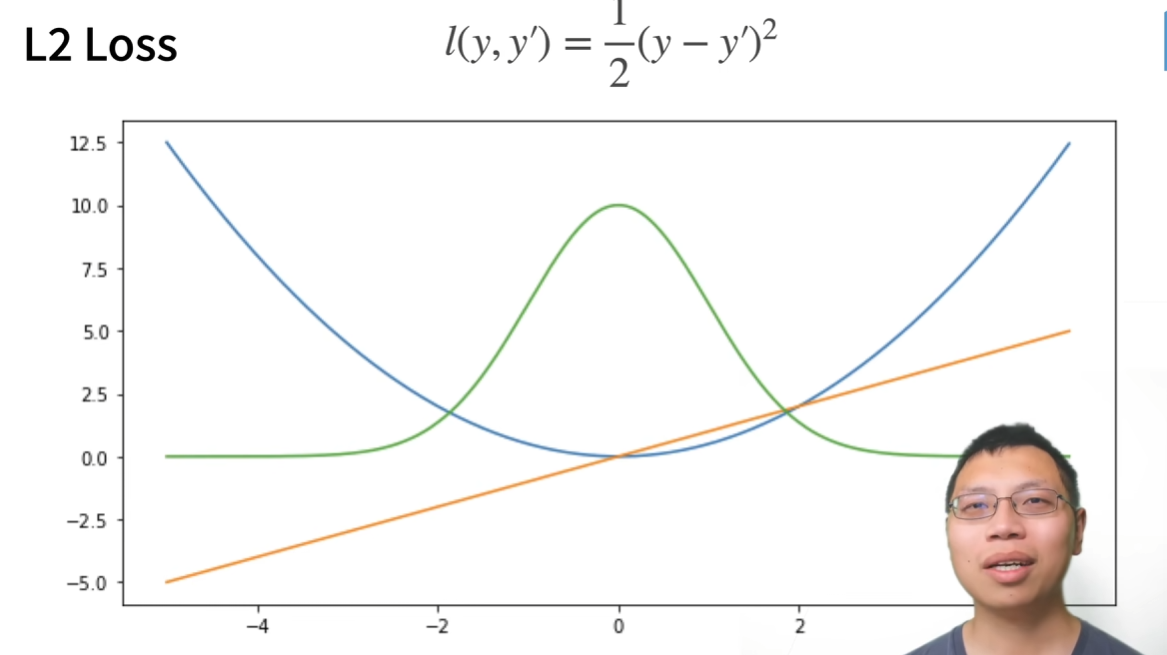
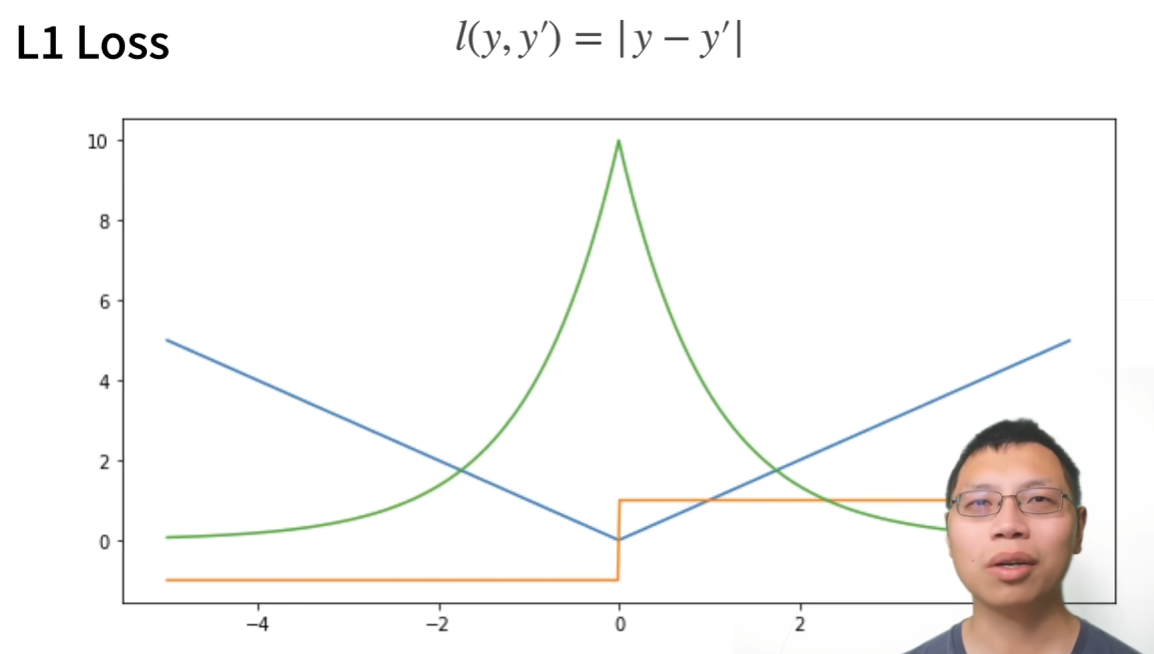
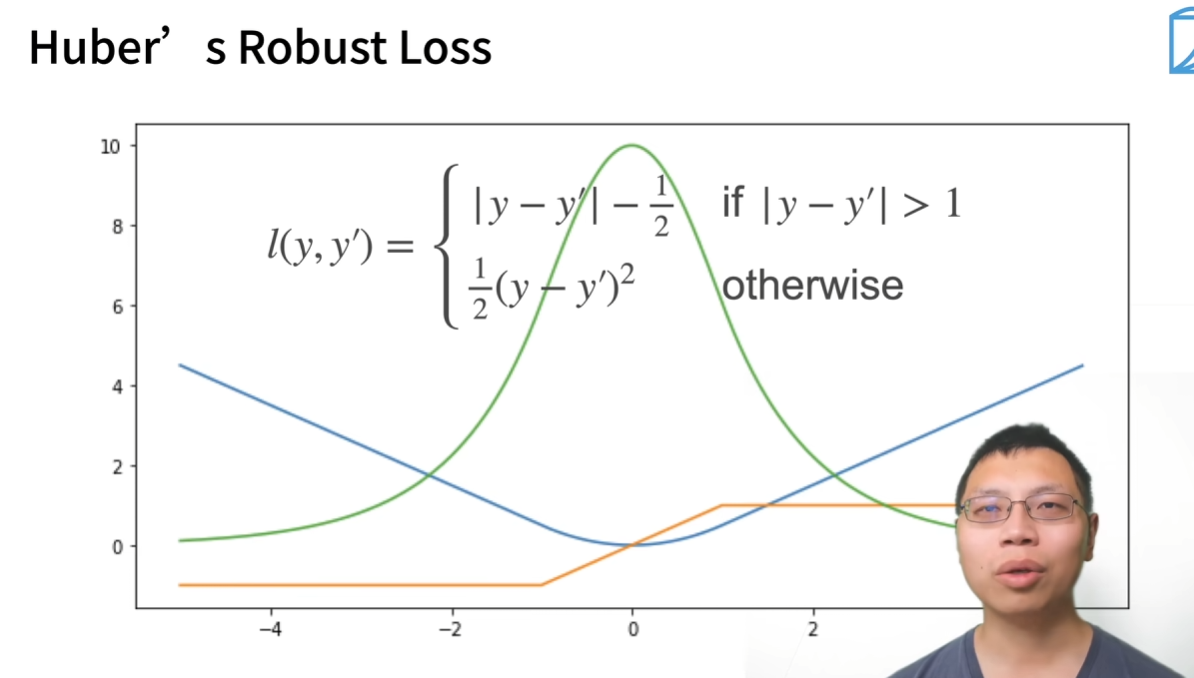

In [8]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

#ToTensor实例将图像数据从PIL类型变换成为32位浮点数格式
#并除以255使得所有像素的数值均在0-1之前
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root="../data",train=True,
                                               transform=trans,
                                               download=True)

mnist_test = torchvision.datasets.FashionMNIST(root="../data",train=False,
                                              transform=trans,
                                              download=True)
len(mnist_train),len(mnist_test)

(60000, 10000)

In [9]:
mnist_train[0][0].shape,mnist_test[0][0].shape

(torch.Size([1, 28, 28]), torch.Size([1, 28, 28]))

In [10]:
def get_fashion_mnist_labels(labels):
    """返回数据集文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]


def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes


array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

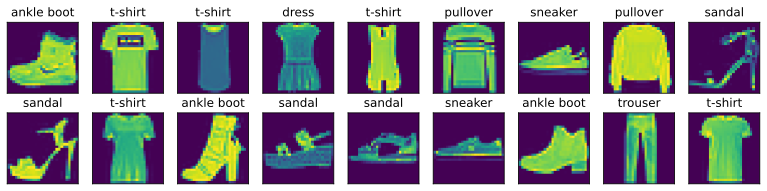

In [11]:
X,y =next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_images(X.reshape(18,28,28),2,9,titles=get_fashion_mnist_labels(y))

In [12]:
batch_size=256
def get_dataloader_workers():
    #"使用四个进程来读取数据"
    return 4

train_iter = data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers=get_dataloader_workers())

timer=d2l.Timer()
for X ,y in train_iter:
    continue
f'{timer.stop():.2f}sec'

'6.46sec'

In [17]:
import torch 
from IPython import display
from d2l import torch as d2l

batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)


In [19]:
#展平每一个图像
num_inputs = 784
num_outputs=10

W=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b=torch.zeros(num_outputs,requires_grad=True)

In [20]:
X = torch.tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]])
X.sum(0,keepdim=True),X.sum(1,keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [ ]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1,keepdim=True) #保持维数
    return X_exp/partiton #应用了广播机制

In [21]:
X=torch.normal(0,1,(2,5))
X_prob = softmax(X)
X_prob,X_prob.sum(1)

(tensor([[0.1092, 0.3715, 0.1904, 0.1463, 0.1827],
         [0.1845, 0.0167, 0.5433, 0.1682, 0.0873]]),
 tensor([1.0000, 1.0000]))

In [3]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1,W.shape[0])),W)+b)

In [23]:
#实现交叉熵损失
y = torch.tensor([0,2])
y_hat = torch.tensor([[0.1,0.3,0.6],[0.3,0.2,0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [25]:
def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)),y]) #对实际分类的概率取负对数，直接提取对应类别概率矩阵子块

cross_entropy(y_hat,y)

tensor([2.3026, 0.6931])

In [30]:
#计算预测正确的数量：准确率
def accuracy(y_hat,y):
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1)
    cmp=y_hat.type(y.dtype)==y
    return float(cmp.type(y.dtype).sum())

accuracy(y_hat,y) / len(y)

0.5

In [1]:
#评估任意模型的准确率:
def evaluate_accuracy(net,data_iter):
    if isinstance(net,torch.nn.Module):
        net.eval() #设置为评估模式
    metric = Accumulator(2) #正确预测数，预测总数
    for X,y in data_iter:
        metric.add(accuracy(net(X),y),y.numel())
    return metric[0] / metric[1]
    

In [13]:
class Accumulator:
    def __init__(self,n):
        self.data=[0.0]*n
        
    def add(self,*args):
        self.data=[a+float(b) for a,b in zip(self.data,args)]
        
    def reset(self):
        self.data=[0.0]*len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]

In [15]:
import torch 
from torch import nn
from d2l import torch as d2l

batch_size=256
train_iter,test_iter = d2l.load_data_fashion_mnist(batch_size)
#定义展平层，在线性层前调整网络输入的形状,只保留第0维度，剩下维度全部展平为向量，相当于把输入都调整成为二维
net = nn.Sequential(nn.Flatten(),nn.Linear(784,10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,std=0.01)

net.apply(init_weights);

#在交叉熵损失函数中传递未归一化的预测，并同时计算softmax及其对数
loss = nn.CrossEntropyLoss()
#使用学习率为0.1的小批量随机梯度下降作为优化算法
trainer = torch.optim.SGD(net.parameters(),lr=0.1)

num_epochs=10
d2l.train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)


AttributeError: module 'd2l.torch' has no attribute 'train_ch3'